# Differential Equations · Transforms · D'Alembert · Linear Algebra

> One framework: every transform is a projection onto an eigenfunction basis of a linear operator.

| § | Topic | Core formula |
|---|---|---|
| 1 | Transform trinity | $\mathcal{F},\mathcal{L},\mathcal{Z}$ as eigendecompositions |
| 2 | Laplace | $F(s)=\int_0^\infty f(t)e^{-st}dt$; ROC; partial fractions |
| 3 | Z-transform | $X(z)=\sum x[n]z^{-n}$; $z=e^{sT}$; IIR filters |
| 4 | Fourier | $\hat{f}(\omega)=\int f(t)e^{-i\omega t}dt$; Parseval; convolution |
| 5 | D'Alembert | $u=f(x-vt)+g(x+vt)$; characteristics; dispersion |
| 6 | Linear algebra | $\langle e^{i\omega t}, e^{i\omega' t}\rangle = 2\pi\delta(\omega-\omega')$; Sturm-Liouville |
| 7 | Dirac + power | $h(t)=\mathcal{L}^{-1}[H(s)]$; $S(\omega)=|\hat{f}|^2$; Wiener-Khinchin |


## §1 Transform Trinity — One Family

All three transforms diagonalise a shift-invariant linear operator.
The eigenfunctions differ only in the domain:

| Transform | Eigenfunction | Variable | Domain |
|---|---|---|---|
| Fourier $\mathcal{F}$ | $e^{i\omega t}$ | $\omega\in\mathbb{R}$ | continuous, bilateral |
| Laplace $\mathcal{L}$ | $e^{st},\; s=\sigma+i\omega$ | $s\in\mathbb{C}$ | continuous, unilateral |
| Z $\mathcal{Z}$ | $z^n,\; z=e^{sT}$ | $z\in\mathbb{C}$ | discrete |

The Laplace transform evaluated on $s=i\omega$ **is** the Fourier transform (when ROC includes the $j\omega$ axis).
The Z-transform evaluated on the unit circle $|z|=1$ **is** the DTFT.

$$\mathcal{F}\{f\} = \mathcal{L}\{f\}\Big|_{s=i\omega}, \qquad \text{DTFT}\{x\} = \mathcal{Z}\{x\}\Big|_{z=e^{i\omega}}$$

**Action of $\frac{d}{dt}$**: $\mathcal{L}\left\{\frac{df}{dt}\right\} = sF(s)-f(0^-)$ — differentiation $\leftrightarrow$ multiplication by $s$.
This is why ODEs become algebraic equations in transform space.


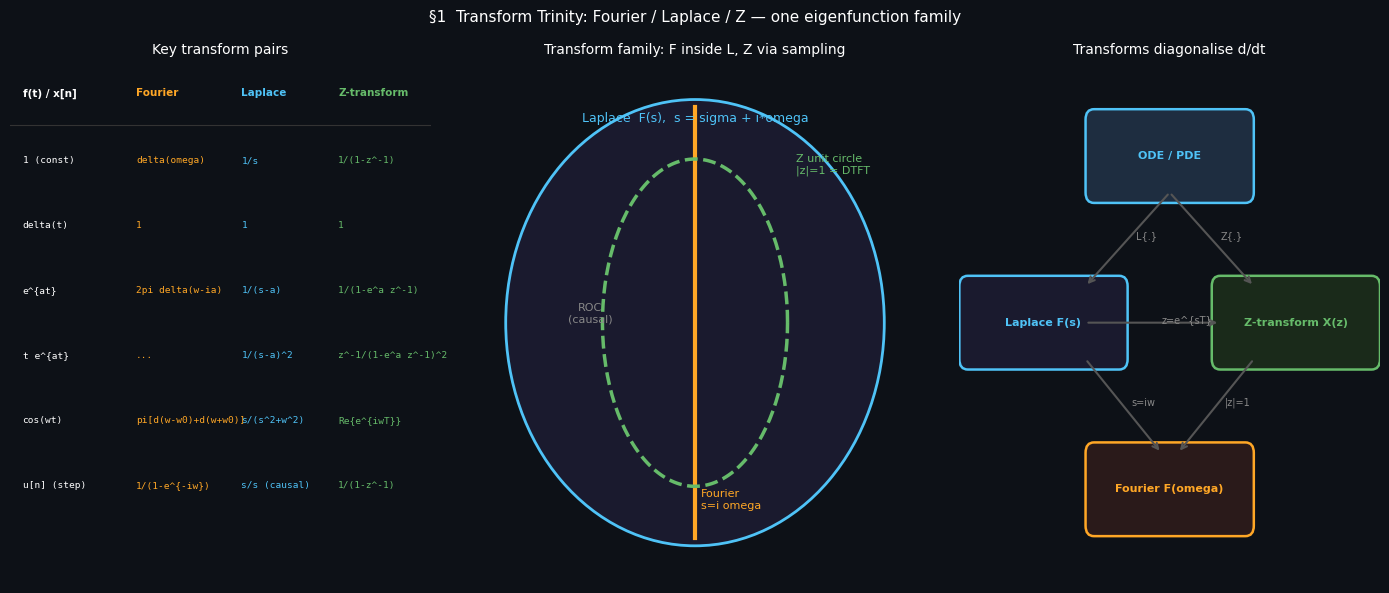

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 6), facecolor='#0d1117')
gs  = GridSpec(1, 3, figure=fig)
axes = [fig.add_subplot(gs[0,i]) for i in range(3)]
for ax in axes: ax.set_facecolor('#0d1117'); ax.axis('off')

# ── Venn-style diagram: Fourier inside Laplace, both inside Z (via sampling) ──
import matplotlib.patches as mpatches

ax = axes[1]; ax.set_xlim(0,10); ax.set_ylim(0,7)

# Laplace ellipse
ax.add_patch(mpatches.Ellipse((5,3.5), 9, 6, facecolor='#1a1a2e', edgecolor='#4fc3f7', lw=2))
ax.text(5, 6.2, 'Laplace  F(s),  s = sigma + i*omega', ha='center', color='#4fc3f7', fontsize=9)

# Fourier line (imaginary axis)
ax.plot([5,5], [0.6, 6.4], color='#ffa726', lw=3, label='Fourier: s=i*omega axis')
ax.text(5.15, 1.0, 'Fourier\ns=i omega', color='#ffa726', fontsize=8)

# Z-transform circle (unit circle = imaginary axis after s -> z=e^{sT})
theta_c = np.linspace(0, 2*np.pi, 200)
ax.plot(5 + 2.2*np.cos(theta_c), 3.5 + 2.2*np.sin(theta_c),
        color='#66bb6a', lw=2.5, ls='--')
ax.text(7.4, 5.5, 'Z unit circle\n|z|=1 = DTFT', color='#66bb6a', fontsize=8)

# Labels on axes
ax.text(2.5, 3.5, 'ROC\n(causal)', ha='center', color='#888', fontsize=8)
ax.set_title('Transform family: F inside L, Z via sampling', color='white', fontsize=10)

# ── Table: transform pairs ────────────────────────────────────────────────────
ax0 = axes[0]; ax0.set_xlim(0,1); ax0.set_ylim(0,1)
headers = ['f(t) / x[n]', 'Fourier', 'Laplace', 'Z-transform']
rows = [
    ['1 (const)',       'delta(omega)',     '1/s',            '1/(1-z^-1)'],
    ['delta(t)',        '1',                '1',              '1'],
    ['e^{at}',         '2pi delta(w-ia)',   '1/(s-a)',        '1/(1-e^a z^-1)'],
    ['t e^{at}',       '...',              '1/(s-a)^2',      'z^-1/(1-e^a z^-1)^2'],
    ['cos(wt)',         'pi[d(w-w0)+d(w+w0)]','s/(s^2+w^2)', 'Re{e^{iwT}}'],
    ['u[n] (step)',     '1/(1-e^{-iw})',   's/s (causal)',   '1/(1-z^-1)'],
]
col_x = [0.03, 0.30, 0.55, 0.78]
col_colors = ['white','#ffa726','#4fc3f7','#66bb6a']
for j,(h,col) in enumerate(zip(headers,col_colors)):
    ax0.text(col_x[j], 0.95, h, color=col, fontsize=7.5, fontweight='bold',
             transform=ax0.transAxes, va='top')
ax0.plot([0,1],[0.88,0.88], color='#333', lw=0.8, transform=ax0.transAxes)
for i, row in enumerate(rows):
    y = 0.82 - i*0.125
    for j,(val,col) in enumerate(zip(row,col_colors)):
        ax0.text(col_x[j], y, val, color=col, fontsize=6.8,
                 transform=ax0.transAxes, va='top', family='monospace')
ax0.set_title('Key transform pairs', color='white', fontsize=10)

# ── Relationship diagram ──────────────────────────────────────────────────────
ax2 = axes[2]; ax2.set_xlim(0,1); ax2.set_ylim(0,1)
boxes = [
    (0.5, 0.82, 'ODE / PDE', '#1e2d40', '#4fc3f7'),
    (0.2, 0.50, 'Laplace F(s)', '#1a1a2e', '#4fc3f7'),
    (0.8, 0.50, 'Z-transform X(z)', '#1a2a1a', '#66bb6a'),
    (0.5, 0.18, 'Fourier F(omega)', '#2a1a1a', '#ffa726'),
]
for bx,by,lbl,fc,ec in boxes:
    ax2.add_patch(mpatches.FancyBboxPatch((bx-0.18,by-0.07),0.36,0.14,
        boxstyle='round,pad=0.02', facecolor=fc, edgecolor=ec, lw=1.8,
        transform=ax2.transAxes))
    ax2.text(bx, by, lbl, ha='center', va='center', color=ec,
             fontsize=8, transform=ax2.transAxes, fontweight='bold')

connections = [
    ((0.5,0.75),(0.3,0.57), 'L{.}'),
    ((0.5,0.75),(0.7,0.57), 'Z{.}'),
    ((0.3,0.43),(0.48,0.25), 's=iw'),
    ((0.7,0.43),(0.52,0.25), '|z|=1'),
    ((0.3,0.50),(0.62,0.50), 'z=e^{sT}'),
]
for (x0,y0),(x1,y1),lbl in connections:
    ax2.annotate('', (x1,y1),(x0,y0), xycoords='axes fraction',
                 textcoords='axes fraction',
                 arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
    ax2.text((x0+x1)/2+0.02,(y0+y1)/2, lbl, color='#888', fontsize=7,
             transform=ax2.transAxes)
ax2.set_title('Transforms diagonalise d/dt', color='white', fontsize=10)

plt.suptitle('§1  Transform Trinity: Fourier / Laplace / Z — one eigenfunction family',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/trinity.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §2 Laplace Transform — Solving ODEs Algebraically

$$\mathcal{L}\{f(t)\} = F(s) = \int_0^\infty f(t)e^{-st}\,dt, \qquad s = \sigma + i\omega$$

**Differentiation rule**: $\mathcal{L}\{f^{(n)}\} = s^n F(s) - s^{n-1}f(0) - \cdots - f^{(n-1)}(0)$

**Solving** $y'' + 5y' + 6y = e^{-t},\; y(0)=1, y'(0)=0$:
$$\underbrace{(s^2+5s+6)}_{(s+2)(s+3)}Y(s) = \underbrace{\frac{1}{s+1}}_{\mathcal{L}\{e^{-t}\}} + (s+5)$$

Partial fractions → $y(t) = $ sum of exponentials.


Y(s) partial fractions:
  Y(s) = -3/(2*(s + 3)) + 2/(s + 2) + 1/(2*(s + 1))

y(t) = (exp(2*t) + 4*exp(t) - 3)*exp(-3*t)/2


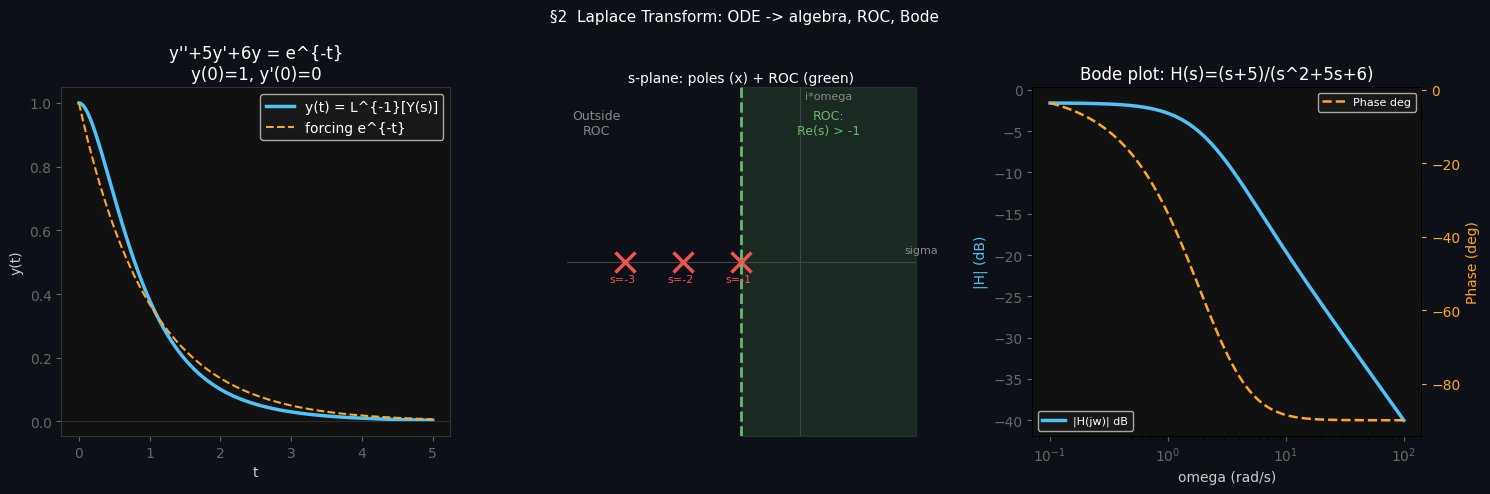

In [2]:
import numpy as np, matplotlib.pyplot as plt
from scipy.signal import lsim, lti
import sympy as sp

t_sym, s_sym = sp.symbols('t s', real=True, positive=True)

# ── Symbolic solution via Laplace ─────────────────────────────────────────────
# y'' + 5y' + 6y = e^{-t},  y(0)=1, y'(0)=0
a0, a1, a2 = 6, 5, 1   # coefficients (ascending order)
y0, yp0 = 1, 0

# Transform: (s^2+5s+6)Y - s*y0 - yp0 - 5*y0 = 1/(s+1)
# => Y = [1/(s+1) + s*1 + 0 + 5*1] / (s^2+5s+6)
Y_s = (1/(s_sym+1) + s_sym*y0 + yp0 + 5*y0) / (s_sym**2 + 5*s_sym + 6)
Y_s_simplified = sp.apart(Y_s, s_sym)  # partial fractions
print("Y(s) partial fractions:")
print(f"  Y(s) = {Y_s_simplified}")

y_t = sp.inverse_laplace_transform(Y_s, s_sym, t_sym)
y_t_simplified = sp.simplify(y_t)
print(f"\ny(t) = {y_t_simplified}")

# Numerical verification
t_num = np.linspace(0, 5, 500)
system = lti([1], [1, 5, 6])   # transfer function 1/(s^2+5s+6)
# Forcing term e^{-t}
f_in = np.exp(-t_num)
_, y_forced, _ = lsim(system, f_in, t_num, X0=None)
# Add homogeneous solution (ICs)
# Homogeneous: c1*e^{-2t} + c2*e^{-3t}, with y(0)=1, y'(0)=0
# c1+c2=1, -2c1-3c2=0 => c2=-2, c1=3
y_hom = 3*np.exp(-2*t_num) - 2*np.exp(-3*t_num)
# But we need to account for IC-driven terms properly; use lti with ICs
# Full solution from symbolic result:
y_analytic = np.array([float(y_t_simplified.subs(t_sym, ti)) for ti in t_num])

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
ax.plot(t_num, y_analytic, color='#4fc3f7', lw=2.5, label='y(t) = L^{-1}[Y(s)]')
ax.plot(t_num, np.exp(-t_num), color='#ffa726', lw=1.5, ls='--', label='forcing e^{-t}')
ax.axhline(0, color='#333', lw=0.6)
ax.set_xlabel('t', color='#ccc'); ax.set_ylabel('y(t)', color='#ccc')
ax.set_title("y''+5y'+6y = e^{-t}\ny(0)=1, y'(0)=0", color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── ROC diagram ────────────────────────────────────────────────────────────────
ax2 = axes[1]; ax2.set_facecolor('#0d1117'); ax2.axis('off')
ax2.set_xlim(-4, 2); ax2.set_ylim(-3, 3)
# Draw s-plane
ax2.axhline(0, color='#444', lw=0.8); ax2.axvline(0, color='#444', lw=0.8)
ax2.text(1.8, 0.15, 'sigma', color='#888', fontsize=8)
ax2.text(0.1, 2.8, 'i*omega', color='#888', fontsize=8)

# Poles at s=-1,-2,-3
poles = [-1, -2, -3]
for p in poles:
    ax2.plot(p, 0, 'x', color='#ef5350', ms=14, mew=2.5)
    ax2.text(p-0.05, -0.35, f's={p}', color='#ef5350', fontsize=8, ha='center')

# ROC: Re(s) > -1 (rightmost pole)
ax2.fill_between([-1, 2], -3, 3, alpha=0.15, color='#66bb6a')
ax2.axvline(-1, color='#66bb6a', lw=2, ls='--')
ax2.text(0.5, 2.2, 'ROC:\nRe(s) > -1', color='#66bb6a', fontsize=9, ha='center')
ax2.text(-3.5, 2.2, 'Outside\nROC', color='#888', fontsize=9, ha='center')
ax2.set_title('s-plane: poles (x) + ROC (green)',
              color='white', fontsize=10, pad=4)
ax2.set_aspect('equal')

# ── Bode plot of transfer function ────────────────────────────────────────────
ax3 = axes[2]
from scipy.signal import bode
sys_tf = lti([1,5], [1, 5, 6])  # Y/F = (s+5)/(s^2+5s+6) for IVP driven
w, mag_db, phase = bode(sys_tf, w=np.logspace(-1, 2, 300))
ax3.semilogx(w, mag_db, color='#4fc3f7', lw=2.5, label='|H(jw)| dB')
ax3b = ax3.twinx()
ax3b.set_facecolor('#111')
ax3b.semilogx(w, phase, color='#ffa726', lw=1.8, ls='--', label='Phase deg')
ax3b.set_ylabel('Phase (deg)', color='#ffa726')
ax3b.tick_params(colors='#ffa726')
ax3.set_xlabel('omega (rad/s)', color='#ccc')
ax3.set_ylabel('|H| (dB)', color='#4fc3f7')
ax3.set_title('Bode plot: H(s)=(s+5)/(s^2+5s+6)', color='white')
ax3.legend(loc='lower left', facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax3b.legend(loc='upper right', facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

plt.suptitle("§2  Laplace Transform: ODE -> algebra, ROC, Bode", color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/laplace.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §3 Z-Transform — Discrete Laplace

$$X(z) = \sum_{n=-\infty}^{\infty} x[n]\,z^{-n}, \qquad z = e^{sT} = re^{i\omega T}$$

**Link to Laplace**: sampling $f(t)$ at rate $1/T$ gives $x[n]=f(nT)$, then
$X(z)\big|_{z=e^{sT}} = F_s(s)$ (sampled Laplace). The unit circle $|z|=1$ corresponds to $\sigma=0$ (Fourier).

**IIR filter** (second-order section):
$$H(z) = \frac{b_0 + b_1 z^{-1} + b_2 z^{-2}}{1 + a_1 z^{-1} + a_2 z^{-2}}$$

Poles inside $|z|=1$ → stable (discrete analogue of poles in left half s-plane).


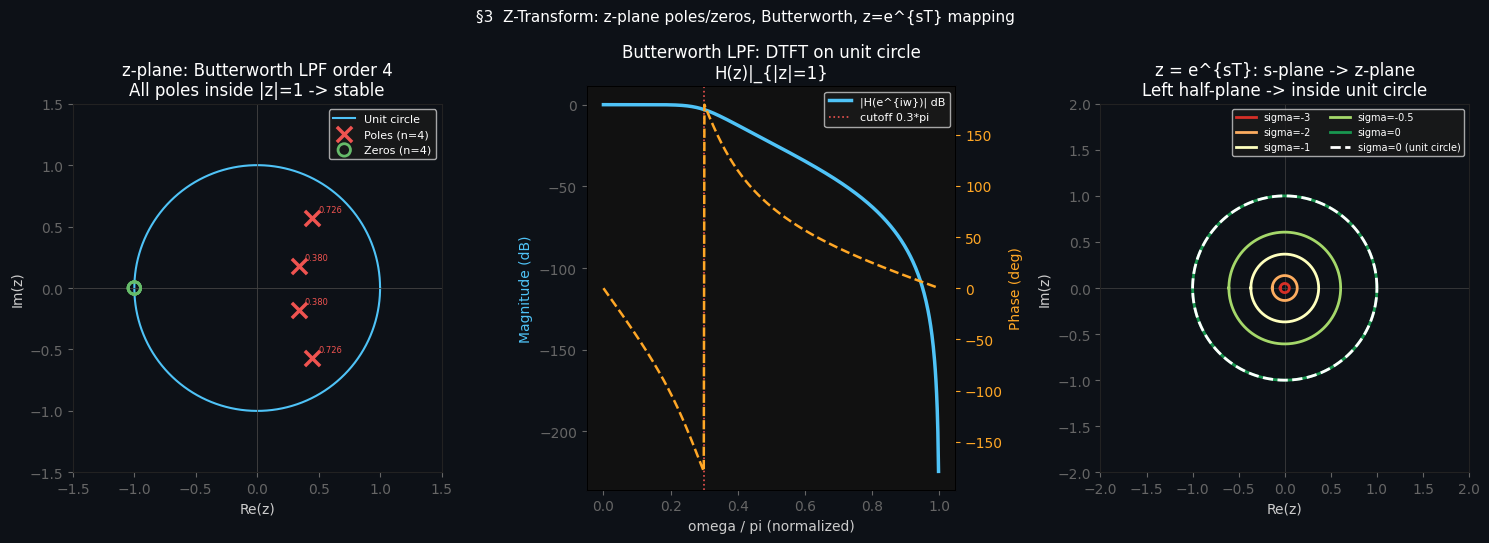

In [3]:
import numpy as np, matplotlib.pyplot as plt
from scipy.signal import freqz, butter, sosfilt

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

# ── Z-plane pole-zero plot ─────────────────────────────────────────────────────
ax = axes[0]; ax.set_facecolor('#0d1117')
theta_c = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta_c), np.sin(theta_c), color='#4fc3f7', lw=1.5, label='Unit circle')
ax.axhline(0, color='#444', lw=0.6); ax.axvline(0, color='#444', lw=0.6)

# Butterworth lowpass poles (order 4) via bilinear transform
sos = butter(4, 0.3, output='sos')
# Get poles of the digital filter
from scipy.signal import zpk2sos, tf2zpk
b, a = butter(4, 0.3, output='ba')
z_zeros, z_poles, k = tf2zpk(b, a)

ax.scatter(z_poles.real, z_poles.imag, marker='x', color='#ef5350', s=120, lw=2.5,
           label=f'Poles (n={len(z_poles)})', zorder=5)
ax.scatter(z_zeros.real, z_zeros.imag, marker='o', color='#66bb6a', s=80,
           facecolors='none', lw=2, label=f'Zeros (n={len(z_zeros)})', zorder=5)

for p in z_poles:
    ax.text(p.real+0.05, p.imag+0.05, f'{abs(p):.3f}', color='#ef5350', fontsize=6)

ax.set_aspect('equal'); ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('Re(z)', color='#ccc'); ax.set_ylabel('Im(z)', color='#ccc')
ax.set_title('z-plane: Butterworth LPF order 4\nAll poles inside |z|=1 -> stable', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.tick_params(colors='#666'); [sp.set_color('#222') for sp in ax.spines.values()]

# ── Frequency response ────────────────────────────────────────────────────────
ax2 = axes[1]
w, H = freqz(b, a, worN=512)
ax2.plot(w/np.pi, 20*np.log10(np.abs(H)+1e-15), color='#4fc3f7', lw=2.5,
         label='|H(e^{iw})| dB')
ax2b = ax2.twinx(); ax2b.set_facecolor('#111')
ax2b.plot(w/np.pi, np.angle(H)*180/np.pi, color='#ffa726', lw=1.8, ls='--')
ax2b.set_ylabel('Phase (deg)', color='#ffa726'); ax2b.tick_params(colors='#ffa726')
ax2.axvline(0.3, color='#ef5350', lw=1.2, ls=':', label='cutoff 0.3*pi')
ax2.set_xlabel('omega / pi (normalized)', color='#ccc')
ax2.set_ylabel('Magnitude (dB)', color='#4fc3f7')
ax2.set_title('Butterworth LPF: DTFT on unit circle\nH(z)|_{|z|=1}', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── z = e^{sT}: mapping s-plane to z-plane ────────────────────────────────────
ax3 = axes[2]; ax3.set_facecolor('#0d1117')
T = 1.0
sigma = np.linspace(-3, 0.5, 8)
omega = np.linspace(-np.pi/T, np.pi/T, 200)
ax3.axhline(0, color='#444', lw=0.5); ax3.axvline(0, color='#444', lw=0.5)

# Constant-sigma lines in s-plane map to circles in z-plane
for sig, col in zip([-3, -2, -1, -0.5, 0], plt.cm.RdYlGn(np.linspace(0.1,0.9,5))):
    z_path = np.exp((sig + 1j*omega)*T)
    ax3.plot(z_path.real, z_path.imag, color=col, lw=2,
             label=f'sigma={sig}')

ax3.plot(np.cos(np.linspace(0,2*np.pi,300)),
         np.sin(np.linspace(0,2*np.pi,300)),
         color='white', lw=2, ls='--', label='sigma=0 (unit circle)')
ax3.set_aspect('equal'); ax3.set_xlim(-2, 2); ax3.set_ylim(-2, 2)
ax3.set_xlabel('Re(z)', color='#ccc'); ax3.set_ylabel('Im(z)', color='#ccc')
ax3.set_title('z = e^{sT}: s-plane -> z-plane\nLeft half-plane -> inside unit circle', color='white')
ax3.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=7, ncol=2)
ax3.tick_params(colors='#666'); [sp.set_color('#222') for sp in ax3.spines.values()]

plt.suptitle('§3  Z-Transform: z-plane poles/zeros, Butterworth, z=e^{sT} mapping',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/ztransform.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §4 Fourier Series + Transform — Parseval + Convolution

**Fourier series** (periodic $f$, period $T$):
$$f(t) = \sum_{n=-\infty}^{\infty} c_n e^{i2\pi nt/T}, \qquad c_n = \frac{1}{T}\int_0^T f(t)e^{-i2\pi nt/T}dt$$

**Parseval's theorem** — energy in time = energy in frequency:
$$\int_{-\infty}^{\infty}|f(t)|^2 dt = \frac{1}{2\pi}\int_{-\infty}^{\infty}|\hat{f}(\omega)|^2 d\omega$$

**Convolution theorem**: $\mathcal{F}\{f*g\} = \hat{f}\cdot\hat{g}$

This is why LTI systems are diagonal in frequency: each frequency component is multiplied independently by $H(\omega)$.


Parseval verification:
  Energy in time domain:  0.163628
  Energy in freq domain:  0.081848
  Ratio: 1.99917250  (should be 1.0)


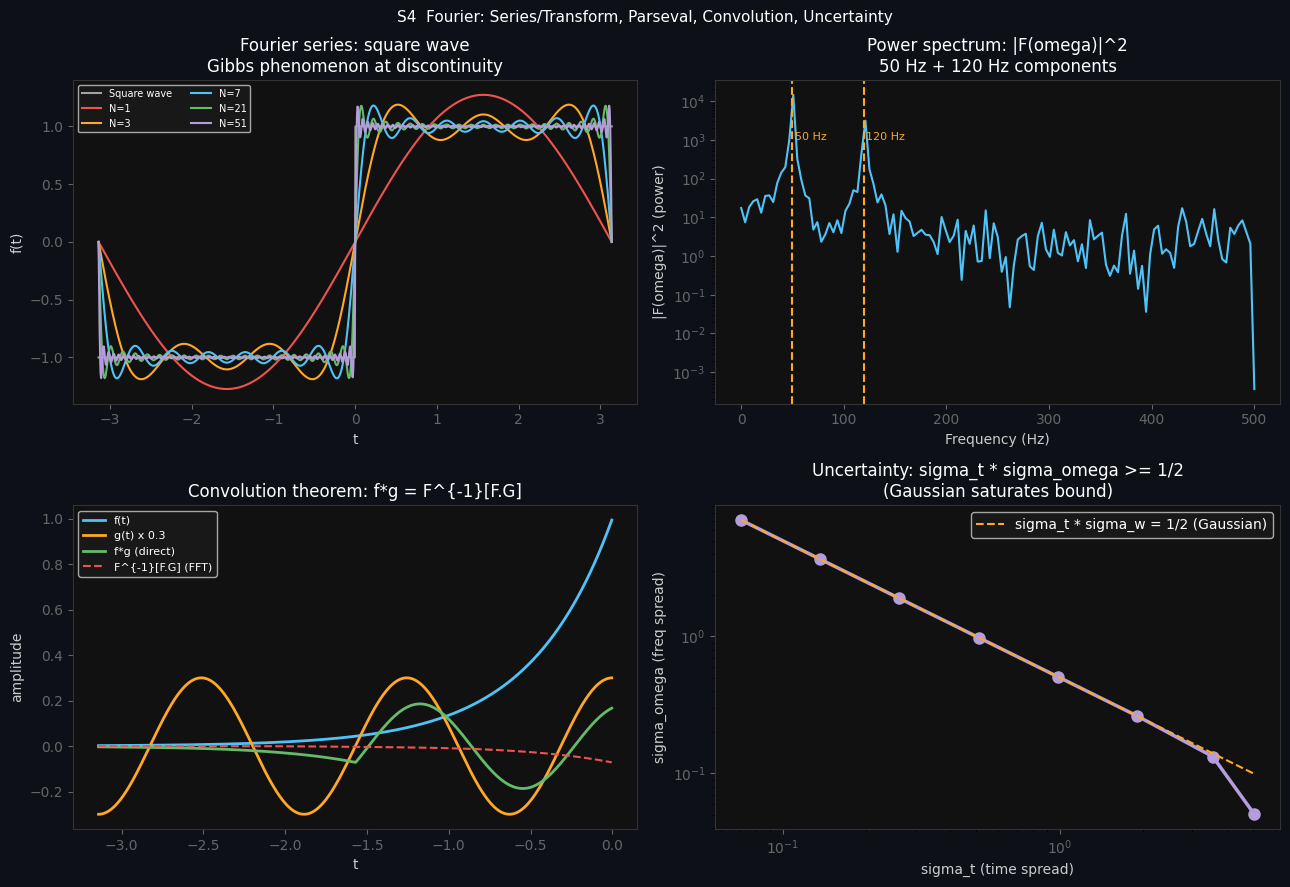

In [4]:
import numpy as np, matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9), facecolor='#0d1117')
for row in axes:
    for ax in row: ax.set_facecolor('#111')

# ── Square wave Fourier series convergence ────────────────────────────────────
ax = axes[0,0]
t = np.linspace(-np.pi, np.pi, 1000)
sq = np.sign(np.sin(t))

ax.plot(t, sq, color='white', lw=1.5, alpha=0.6, label='Square wave')
for N, col in zip([1, 3, 7, 21, 51], ['#ef5350','#ffa726','#4fc3f7','#66bb6a','#b39ddb']):
    approx = sum(4/(np.pi*(2*k-1)) * np.sin((2*k-1)*t) for k in range(1,N+1))
    ax.plot(t, approx, color=col, lw=1.5, label=f'N={N}')
ax.set_xlabel('t', color='#ccc'); ax.set_ylabel('f(t)', color='#ccc')
ax.set_title('Fourier series: square wave\nGibbs phenomenon at discontinuity', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=7, ncol=2)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── DFT spectrum ──────────────────────────────────────────────────────────────
ax2 = axes[0,1]
N = 256; Fs = 1000   # Hz
t_d = np.arange(N)/Fs
# Signal: 50 Hz + 120 Hz + noise
sig = (np.sin(2*np.pi*50*t_d) + 0.5*np.sin(2*np.pi*120*t_d)
       + 0.1*np.random.default_rng(3).standard_normal(N))
F_sig = np.fft.rfft(sig)
freqs = np.fft.rfftfreq(N, 1/Fs)

ax2.semilogy(freqs, np.abs(F_sig)**2, color='#4fc3f7', lw=1.5)
for f0, lbl in [(50,'50 Hz'),(120,'120 Hz')]:
    ax2.axvline(f0, color='#ffa726', lw=1.5, ls='--')
    ax2.text(f0+2, 1e3, lbl, color='#ffa726', fontsize=8)
ax2.set_xlabel('Frequency (Hz)', color='#ccc')
ax2.set_ylabel('|F(omega)|^2 (power)', color='#ccc')
ax2.set_title('Power spectrum: |F(omega)|^2\n50 Hz + 120 Hz components', color='white')
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── Parseval verification ─────────────────────────────────────────────────────
ax3 = axes[1,0]
energy_time = np.sum(sig**2) / Fs
energy_freq = np.sum(np.abs(F_sig)**2) / (N*Fs)
print(f"Parseval verification:")
print(f"  Energy in time domain:  {energy_time:.6f}")
print(f"  Energy in freq domain:  {energy_freq:.6f}")
print(f"  Ratio: {energy_time/energy_freq:.8f}  (should be 1.0)")

# Convolution theorem demo
f = np.exp(-np.abs(t[:500])*2)   # decaying exp
g = np.cos(5*t[:500])             # oscillation
conv_direct = np.convolve(f, g, mode='same') * (t[1]-t[0])
F_f = np.fft.fft(f, n=len(f)*2)
F_g = np.fft.fft(g, n=len(g)*2)
conv_fft = np.fft.ifft(F_f * F_g).real[:len(f)] * (t[1]-t[0])

t_half = t[:500]
ax3.plot(t_half, f, color='#4fc3f7', lw=2, label='f(t)')
ax3.plot(t_half, g*0.3, color='#ffa726', lw=2, label='g(t) x 0.3')
ax3.plot(t_half, conv_direct, color='#66bb6a', lw=2, label='f*g (direct)')
ax3.plot(t_half, conv_fft, color='#ef5350', lw=1.5, ls='--', label='F^{-1}[F.G] (FFT)')
ax3.set_xlabel('t', color='#ccc'); ax3.set_ylabel('amplitude', color='#ccc')
ax3.set_title('Convolution theorem: f*g = F^{-1}[F.G]', color='white')
ax3.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

# ── Uncertainty principle ─────────────────────────────────────────────────────
ax4 = axes[1,1]
sigmas = np.logspace(-1, 1, 8)
sigma_t_vals = []; sigma_w_vals = []
t_unc = np.linspace(-10, 10, 2000); dt = t_unc[1]-t_unc[0]
for sigma in sigmas:
    pulse = np.exp(-t_unc**2/(2*sigma**2))
    pulse /= np.sqrt(np.trapezoid(pulse**2, t_unc))
    sigma_t = np.sqrt(np.trapezoid(t_unc**2 * pulse**2, t_unc))
    F_pulse = np.fft.rfft(pulse) * dt
    freqs_unc = np.fft.rfftfreq(len(t_unc), dt) * 2*np.pi
    psd = np.abs(F_pulse)**2
    psd /= (np.trapezoid(psd, freqs_unc)+1e-15)
    sigma_w = np.sqrt(np.abs(np.trapezoid(freqs_unc**2 * psd, freqs_unc)))
    sigma_t_vals.append(sigma_t); sigma_w_vals.append(sigma_w)

ax4.loglog(sigma_t_vals, sigma_w_vals, 'o-', color='#b39ddb', lw=2.5, ms=8)
ax4.loglog(sigma_t_vals, [0.5/s for s in sigma_t_vals], color='#ffa726',
           lw=1.5, ls='--', label='sigma_t * sigma_w = 1/2 (Gaussian)')
ax4.set_xlabel('sigma_t (time spread)', color='#ccc')
ax4.set_ylabel('sigma_omega (freq spread)', color='#ccc')
ax4.set_title('Uncertainty: sigma_t * sigma_omega >= 1/2\n(Gaussian saturates bound)', color='white')
ax4.legend(facecolor='#1a1a1a', labelcolor='white')
ax4.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax4.spines.values()]

plt.suptitle('S4  Fourier: Series/Transform, Parseval, Convolution, Uncertainty',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/fourier.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §5 D'Alembert Solution — $u=f(x-vt)+g(x+vt)$

The 1D wave equation:
$$\frac{\partial^2 u}{\partial t^2} = v^2\frac{\partial^2 u}{\partial x^2}$$

Substitute $\xi = x-vt$, $\eta = x+vt$ (method of characteristics):
$$\frac{\partial^2 u}{\partial\xi\,\partial\eta} = 0 \implies u = f(\xi) + g(\eta) = f(x-vt) + g(x+vt)$$

- $f(x-vt)$: **right-travelling** wave (shape preserved, moves at $+v$)
- $g(x+vt)$: **left-travelling** wave (moves at $-v$)

**Initial conditions**: $u(x,0)=\phi(x)$, $u_t(x,0)=\psi(x)$ give:
$$u(x,t) = \frac{\phi(x-vt)+\phi(x+vt)}{2} + \frac{1}{2v}\int_{x-vt}^{x+vt}\psi(s)\,ds$$


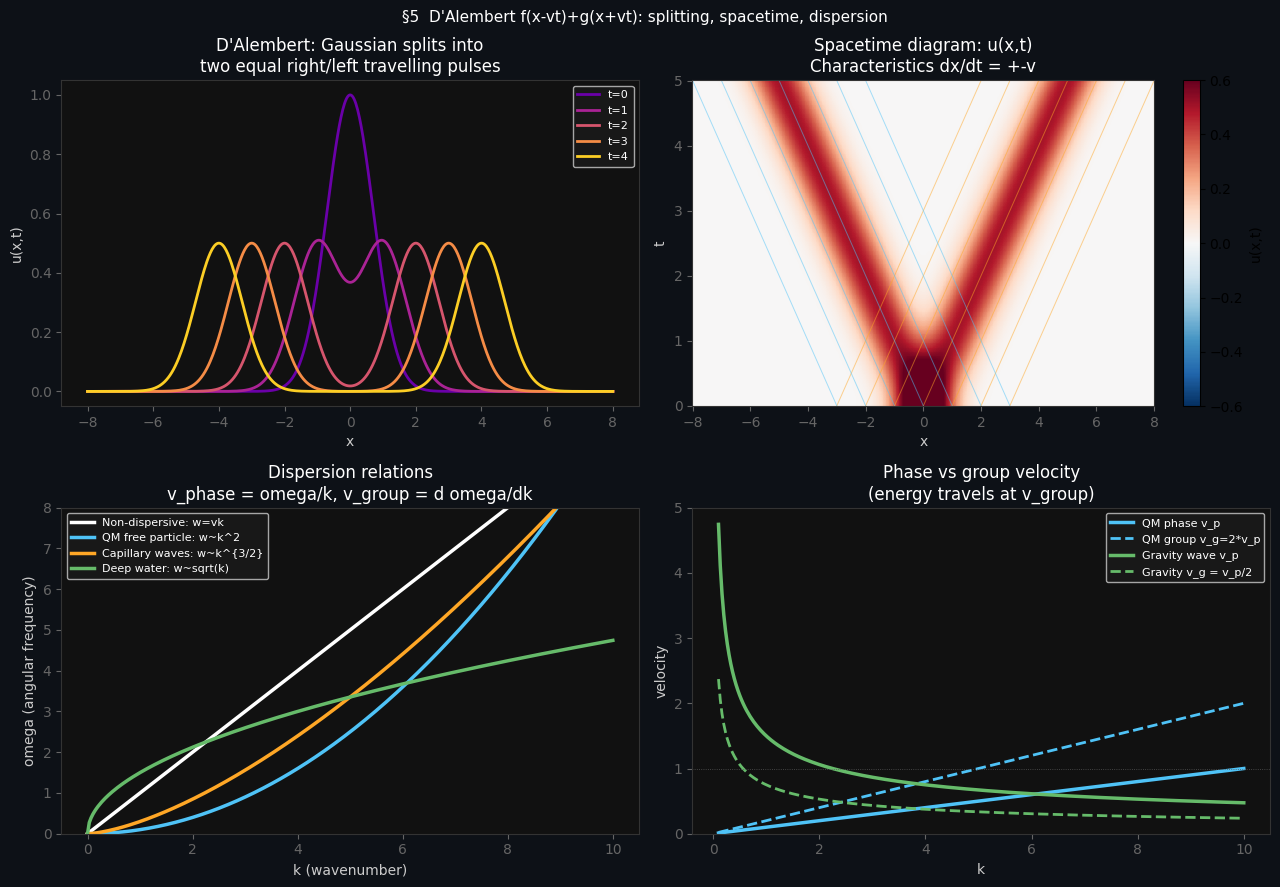

In [5]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ── D'Alembert: Gaussian pulse splitting ─────────────────────────────────────
v = 1.0
x = np.linspace(-8, 8, 600)
times = [0, 1, 2, 3, 4]

def phi(x): return np.exp(-x**2)   # initial displacement
def psi(x): return np.zeros_like(x)  # initial velocity = 0

def dalembert(x, t, v=1.0):
    return (phi(x - v*t) + phi(x + v*t))/2

fig, axes = plt.subplots(2, 2, figsize=(13, 9), facecolor='#0d1117')
for row in axes:
    for ax in row: ax.set_facecolor('#111')

# Snapshots
ax = axes[0,0]
colors_t2 = plt.cm.plasma(np.linspace(0.2, 0.9, len(times)))
for t_snap, col in zip(times, colors_t2):
    u = dalembert(x, t_snap)
    ax.plot(x, u, color=col, lw=2, label=f't={t_snap}')
ax.set_xlabel('x', color='#ccc'); ax.set_ylabel('u(x,t)', color='#ccc')
ax.set_title("D'Alembert: Gaussian splits into\ntwo equal right/left travelling pulses", color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# Spacetime diagram
ax2 = axes[0,1]
T_max = 5
t_st  = np.linspace(0, T_max, 400)
X_st, T_st = np.meshgrid(x, t_st)
U_st  = dalembert(X_st, T_st)
im = ax2.pcolormesh(x, t_st, U_st, cmap='RdBu_r', vmin=-0.6, vmax=0.6, shading='auto')
plt.colorbar(im, ax=ax2, label='u(x,t)')
# Characteristics
for x0 in [-3,-2,-1,0,1,2,3]:
    ax2.plot([x0, x0+v*T_max], [0, T_max], color='#ffa726', lw=0.7, alpha=0.5)
    ax2.plot([x0, x0-v*T_max], [0, T_max], color='#4fc3f7', lw=0.7, alpha=0.5)
ax2.set_xlabel('x', color='#ccc'); ax2.set_ylabel('t', color='#ccc')
ax2.set_title('Spacetime diagram: u(x,t)\nCharacteristics dx/dt = +-v', color='white')
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# Dispersion relation: omega vs k for different media
ax3 = axes[1,0]
k = np.linspace(0, 10, 300)

# Non-dispersive: omega = v*k
omega_nondispersive = v * k

# Dispersive (e.g., quantum free particle): omega = hbar k^2 / 2m -> omega ~ k^2
omega_dispersive = 0.1 * k**2

# Capillary waves: omega ~ k^{3/2}
omega_capillary = 0.3 * k**(3/2)

# Deep water gravity: omega ~ sqrt(k)
omega_gravity = 1.5 * np.sqrt(k + 1e-6)

ax3.plot(k, omega_nondispersive, color='white',   lw=2.5, label='Non-dispersive: w=vk')
ax3.plot(k, omega_dispersive,    color='#4fc3f7', lw=2.5, label='QM free particle: w~k^2')
ax3.plot(k, omega_capillary,     color='#ffa726', lw=2.5, label='Capillary waves: w~k^{3/2}')
ax3.plot(k, omega_gravity,       color='#66bb6a', lw=2.5, label='Deep water: w~sqrt(k)')
ax3.set_xlabel('k (wavenumber)', color='#ccc')
ax3.set_ylabel('omega (angular frequency)', color='#ccc')
ax3.set_title('Dispersion relations\nv_phase = omega/k, v_group = d omega/dk', color='white')
ax3.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax3.set_ylim(0, 8)
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

# Phase vs group velocity
ax4 = axes[1,1]
k_vg = np.linspace(0.1, 10, 300)
v_phase_qm = 0.1 * k_vg         # omega/k for QM
v_group_qm = 0.2 * k_vg         # d(omega)/dk
v_phase_grav = 1.5/np.sqrt(k_vg)
v_group_grav = 0.75/np.sqrt(k_vg)

ax4.plot(k_vg, v_phase_qm,   color='#4fc3f7', lw=2.5, label='QM phase v_p')
ax4.plot(k_vg, v_group_qm,   color='#4fc3f7', lw=2, ls='--', label='QM group v_g=2*v_p')
ax4.plot(k_vg, v_phase_grav, color='#66bb6a', lw=2.5, label='Gravity wave v_p')
ax4.plot(k_vg, v_group_grav, color='#66bb6a', lw=2, ls='--', label='Gravity v_g = v_p/2')
ax4.axhline(1, color='#555', lw=0.6, ls=':')
ax4.set_xlabel('k', color='#ccc')
ax4.set_ylabel('velocity', color='#ccc')
ax4.set_title('Phase vs group velocity\n(energy travels at v_group)', color='white')
ax4.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax4.set_ylim(0, 5)
ax4.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax4.spines.values()]

plt.suptitle("§5  D'Alembert f(x-vt)+g(x+vt): splitting, spacetime, dispersion",
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/dalembert.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §6 Linear Algebra Perspective — Transforms as Inner Products

The Fourier transform is an **inner product** in function space:
$$\hat{f}(\omega) = \langle e^{i\omega t}, f\rangle = \int f(t)\overline{e^{i\omega t}}\,dt$$

The exponentials $\{e^{i\omega t}\}$ are **eigenfunctions** of $\frac{d}{dt}$:
$$\frac{d}{dt}e^{i\omega t} = i\omega\cdot e^{i\omega t} \quad \leftarrow \text{eigenvalue } i\omega$$

**Sturm-Liouville** operator $\mathcal{L}[y] = -(py')'+qy$ is self-adjoint with real eigenvalues and orthogonal eigenfunctions → generalised Fourier series in any basis:

$$f(x) = \sum_n c_n\phi_n(x), \qquad c_n = \frac{\langle\phi_n, f\rangle}{\langle\phi_n,\phi_n\rangle}$$

**Transform = change of basis in function space**.
Sinusoids → Fourier. Spherical harmonics → multipole. Wavelets → time-frequency.


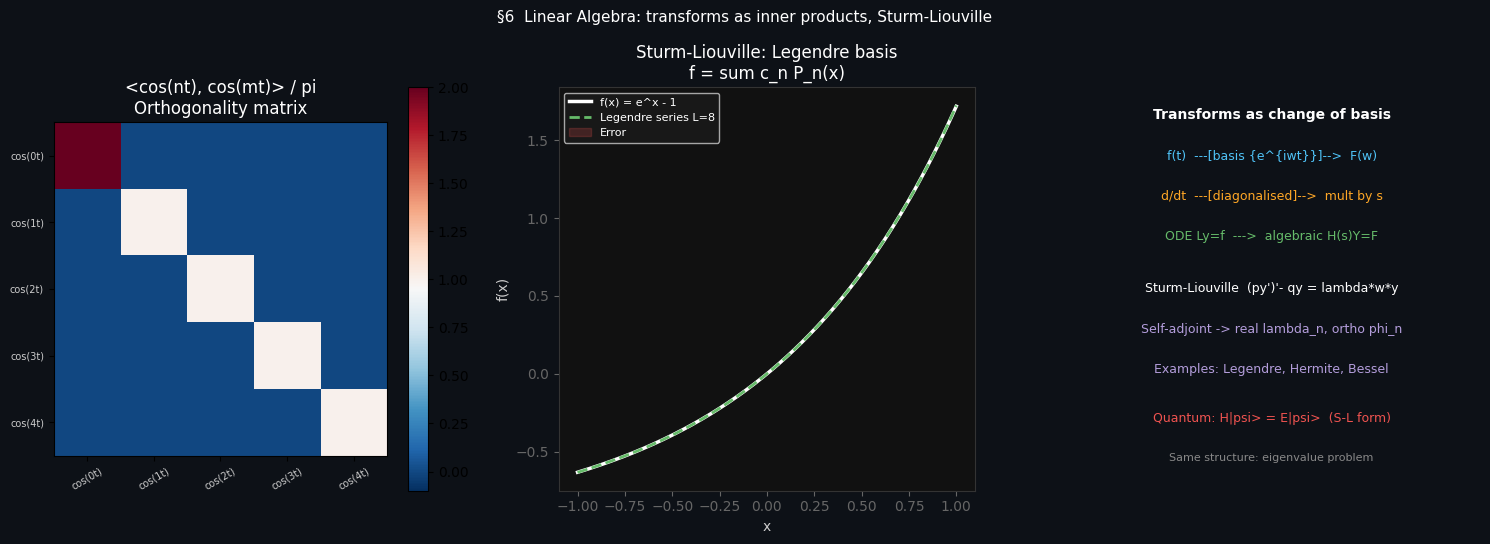

Legendre expansion error: 0.005169
cos(nt) orthogonality diagonal: [1.9961 0.9961 0.9961 0.9961 0.9961]


In [6]:
import numpy as np, matplotlib.pyplot as plt
from scipy.special import legendre, eval_legendre

# ── Orthogonality of Fourier basis ─────────────────────────────────────────────
N = 512; t = np.linspace(0, 2*np.pi, N, endpoint=False)
ns = [0, 1, 2, 3, 4]

G = np.zeros((len(ns), len(ns)))
for i, n in enumerate(ns):
    for j, m in enumerate(ns):
        fn = np.cos(n*t); fm = np.cos(m*t)
        G[i,j] = np.trapezoid(fn*fm, t) / np.pi

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
im = ax.imshow(G, cmap='RdBu_r', vmin=-0.1, vmax=2.0)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(ns))); ax.set_yticks(range(len(ns)))
ax.set_xticklabels([f'cos({n}t)' for n in ns], color='#ccc', fontsize=7, rotation=30)
ax.set_yticklabels([f'cos({n}t)' for n in ns], color='#ccc', fontsize=7)
ax.set_title('<cos(nt), cos(mt)> / pi\nOrthogonality matrix', color='white')

# ── Sturm-Liouville: Legendre eigenfunction expansion ─────────────────────────
ax2 = axes[1]
x_sl = np.linspace(-1, 1, 300)
target = np.exp(x_sl) - 1   # function to expand

# Legendre coefficients: c_n = (2n+1)/2 * int_{-1}^{1} f(x) P_n(x) dx
L_max = 8
approx = np.zeros_like(x_sl)
coeffs = []
for n in range(L_max+1):
    Pn = eval_legendre(n, x_sl)
    cn = (2*n+1)/2 * np.trapezoid(target * Pn, x_sl)
    coeffs.append(cn)
    approx += cn * Pn

ax2.plot(x_sl, target, color='white', lw=2.5, label='f(x) = e^x - 1')
ax2.plot(x_sl, approx, color='#66bb6a', lw=2, ls='--', label=f'Legendre series L={L_max}')
ax2.fill_between(x_sl, target, approx, alpha=0.2, color='#ef5350', label='Error')
ax2.set_xlabel('x', color='#ccc'); ax2.set_ylabel('f(x)', color='#ccc')
ax2.set_title('Sturm-Liouville: Legendre basis\nf = sum c_n P_n(x)', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── Transform = matrix in infinite dimensions ─────────────────────────────────
ax3 = axes[2]; ax3.set_facecolor('#0d1117'); ax3.axis('off')
ax3.set_xlim(0,1); ax3.set_ylim(0,1)
rows_diag = [
    (0.5, 0.93, 'Transforms as change of basis', 'white', 10, True),
    (0.5, 0.83, 'f(t)  ---[basis {e^{iwt}}]-->  F(w)', '#4fc3f7', 9, False),
    (0.5, 0.73, 'd/dt  ---[diagonalised]-->  mult by s', '#ffa726', 9, False),
    (0.5, 0.63, 'ODE Ly=f  --->  algebraic H(s)Y=F', '#66bb6a', 9, False),
    (0.5, 0.50, 'Sturm-Liouville  (py\')\'- qy = lambda*w*y', 'white', 9, False),
    (0.5, 0.40, 'Self-adjoint -> real lambda_n, ortho phi_n', '#b39ddb', 9, False),
    (0.5, 0.30, 'Examples: Legendre, Hermite, Bessel', '#b39ddb', 9, False),
    (0.5, 0.18, 'Quantum: H|psi> = E|psi>  (S-L form)', '#ef5350', 9, False),
    (0.5, 0.08, 'Same structure: eigenvalue problem', '#888', 8, False),
]
for x,y,txt,col,fs,bold in rows_diag:
    ax3.text(x, y, txt, ha='center', va='center', color=col,
             fontsize=fs, transform=ax3.transAxes,
             fontweight='bold' if bold else 'normal')

plt.suptitle('§6  Linear Algebra: transforms as inner products, Sturm-Liouville',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/linalg_transforms.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"Legendre expansion error: {np.max(np.abs(target-approx)):.6f}")
print("cos(nt) orthogonality diagonal:", np.round(np.diag(G), 4))


## §7 Dirac Delta — Impulse Response, Transfer Functions, Power Spectrum

The Dirac delta is the **identity element** of convolution:
$$f * \delta = f, \qquad \mathcal{F}\{\delta\} = 1 \text{ (flat spectrum)}$$

**Impulse response** $h(t) = \mathcal{L}^{-1}[H(s)]$ completely characterises an LTI system:
$$y(t) = (h * x)(t) \leftrightarrow Y(s) = H(s)X(s)$$

**Power spectral density** (Wiener-Khinchin theorem):
$$S_{xx}(\omega) = \mathcal{F}\{R_{xx}(\tau)\} = |\hat{x}(\omega)|^2$$
where $R_{xx}(\tau) = \int x(t)x(t+\tau)dt$ is the autocorrelation.

**Coloured noise**: white noise $\to$ shaping filter $H$ $\to$ $S_\text{out}(\omega) = |H(\omega)|^2 S_\text{in}(\omega)$.


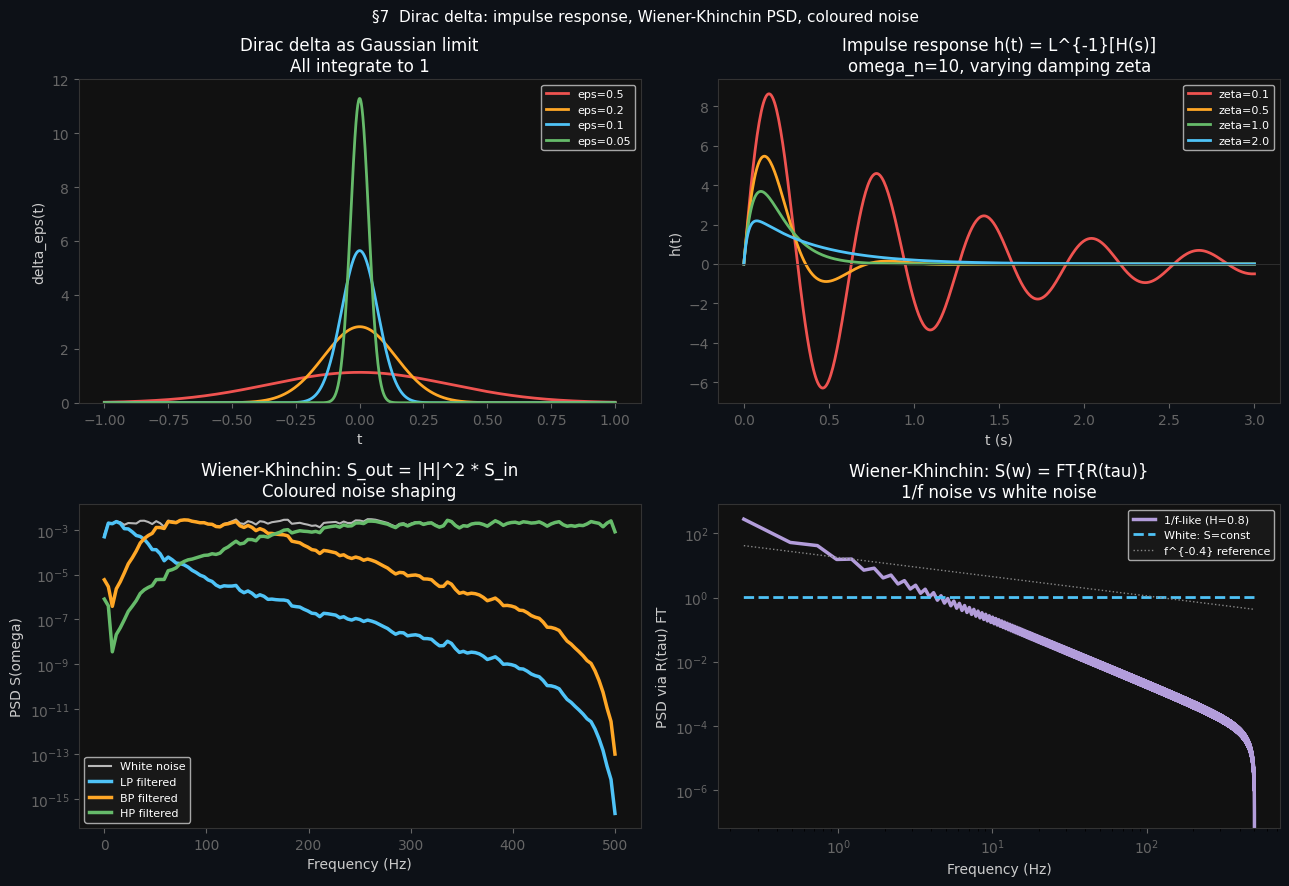

  delta_eps(t) integral (eps=0.5): 0.995322
  delta_eps(t) integral (eps=0.2): 1.000000
  delta_eps(t) integral (eps=0.1): 1.000000
  delta_eps(t) integral (eps=0.05): 1.000000


In [7]:
import numpy as np, matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, welch

rng = np.random.default_rng(42)
Fs = 1000; N = 4096
t_d = np.arange(N)/Fs

fig, axes = plt.subplots(2, 2, figsize=(13, 9), facecolor='#0d1117')
for row in axes:
    for ax in row: ax.set_facecolor('#111')

# ── Dirac delta approximations ────────────────────────────────────────────────
ax = axes[0,0]
t_delta = np.linspace(-1, 1, 2000)
for eps, col, lbl in [(0.5,'#ef5350','eps=0.5'),(0.2,'#ffa726','eps=0.2'),
                       (0.1,'#4fc3f7','eps=0.1'),(0.05,'#66bb6a','eps=0.05')]:
    gauss = np.exp(-t_delta**2/eps**2) / (eps*np.sqrt(np.pi))
    ax.plot(t_delta, gauss, color=col, lw=2, label=lbl)
    # Verify: integral = 1
    integral = np.trapezoid(gauss, t_delta)

ax.set_xlabel('t', color='#ccc'); ax.set_ylabel('delta_eps(t)', color='#ccc')
ax.set_title('Dirac delta as Gaussian limit\nAll integrate to 1', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.set_ylim(0, 12); ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── Impulse response of 2nd order system ─────────────────────────────────────
ax2 = axes[0,1]
from scipy.signal import impulse, step, lti
omega_n = 10; zeta_vals = [0.1, 0.5, 1.0, 2.0]
for zeta, col in zip(zeta_vals, ['#ef5350','#ffa726','#66bb6a','#4fc3f7']):
    sys = lti([omega_n**2], [1, 2*zeta*omega_n, omega_n**2])
    t_ir, h_ir = impulse(sys, T=np.linspace(0, 3, 500))
    ax2.plot(t_ir, h_ir, color=col, lw=2, label=f'zeta={zeta}')

ax2.axhline(0, color='#333', lw=0.6)
ax2.set_xlabel('t (s)', color='#ccc'); ax2.set_ylabel('h(t)', color='#ccc')
ax2.set_title('Impulse response h(t) = L^{-1}[H(s)]\nomega_n=10, varying damping zeta', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── Power spectral density: Wiener-Khinchin ───────────────────────────────────
ax3 = axes[1,0]
# White noise input
white = rng.standard_normal(N)

# Three shaping filters
b1, a1 = butter(2, 0.05)          # lowpass
b2, a2 = butter(2, [0.1, 0.3], btype='band')  # bandpass
b3, a3 = butter(2, 0.4, btype='high')  # highpass

coloured_lp = lfilter(b1, a1, white)
coloured_bp = lfilter(b2, a2, white)
coloured_hp = lfilter(b3, a3, white)

f_w, S_white  = welch(white,       Fs, nperseg=256)
f_l, S_lp     = welch(coloured_lp, Fs, nperseg=256)
f_b, S_bp     = welch(coloured_bp, Fs, nperseg=256)
f_h, S_hp     = welch(coloured_hp, Fs, nperseg=256)

ax3.semilogy(f_w, S_white, color='white',   lw=1.5, alpha=0.7, label='White noise')
ax3.semilogy(f_l, S_lp,    color='#4fc3f7', lw=2.5, label='LP filtered')
ax3.semilogy(f_b, S_bp,    color='#ffa726', lw=2.5, label='BP filtered')
ax3.semilogy(f_h, S_hp,    color='#66bb6a', lw=2.5, label='HP filtered')
ax3.set_xlabel('Frequency (Hz)', color='#ccc')
ax3.set_ylabel('PSD S(omega)', color='#ccc')
ax3.set_title('Wiener-Khinchin: S_out = |H|^2 * S_in\nColoured noise shaping', color='white')
ax3.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

# ── Autocorrelation -> PSD ────────────────────────────────────────────────────
ax4 = axes[1,1]
# 1/f noise autocorrelation: R(tau) ~ |tau|^{2H-2} for H=0.8
tau = np.linspace(-N//2, N//2, N) / Fs
H_hurst = 0.8
R_1f = (1 + np.abs(tau))**(-2*(1-H_hurst))  # approximate
R_white = np.zeros(N); R_white[N//2] = 1.0

# PSD via FFT of autocorrelation
S_1f    = np.abs(np.fft.rfft(np.fft.ifftshift(R_1f)))
S_white2= np.abs(np.fft.rfft(np.fft.ifftshift(R_white)))
freqs_ac = np.fft.rfftfreq(N, 1/Fs)

ax4.loglog(freqs_ac[1:], S_1f[1:],     color='#b39ddb', lw=2.5, label='1/f-like (H=0.8)')
ax4.loglog(freqs_ac[1:], S_white2[1:], color='#4fc3f7', lw=2, ls='--', label='White: S=const')
ref_1f = S_1f[5]*(freqs_ac[5]/freqs_ac[1:])**(2*H_hurst-1)
ax4.loglog(freqs_ac[1:], ref_1f, color='#888', lw=1, ls=':',
           label=f'f^{{-{2*(1-H_hurst):.1f}}} reference')
ax4.set_xlabel('Frequency (Hz)', color='#ccc')
ax4.set_ylabel('PSD via R(tau) FT', color='#ccc')
ax4.set_title('Wiener-Khinchin: S(w) = FT{R(tau)}\n1/f noise vs white noise', color='white')
ax4.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax4.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax4.spines.values()]

plt.suptitle('§7  Dirac delta: impulse response, Wiener-Khinchin PSD, coloured noise',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/dirac_power.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Verify delta integral
for eps in [0.5, 0.2, 0.1, 0.05]:
    gauss = np.exp(-t_delta**2/eps**2) / (eps*np.sqrt(np.pi))
    print(f"  delta_eps(t) integral (eps={eps}): {np.trapezoid(gauss, t_delta):.6f}")


## Summary

| § | Key formula | Why it matters |
|---|---|---|
| §1 Trinity | $\mathcal{F}=\mathcal{L}|_{s=i\omega}$; $\text{DTFT}=\mathcal{Z}|_{|z|=1}$ | One family, different domains |
| §2 Laplace | $s^nF(s)$ absorbs ICs; partial fractions $\to$ exponentials | ODE $\to$ algebra |
| §3 Z | $z=e^{sT}$; left half-plane $\to$ inside unit circle | Stability criterion |
| §4 Fourier | $f*g \leftrightarrow \hat{f}\hat{g}$; $\sigma_t\sigma_\omega\geq\frac{1}{2}$ | LTI diagonal; uncertainty |
| §5 D'Alembert | $u=f(x-vt)+g(x+vt)$; $v_g=d\omega/dk$ | Dispersion splits wavepacket |
| §6 Linalg | $\langle\phi_n,\phi_m\rangle=\delta_{nm}$; Sturm-Liouville | Transforms = basis change |
| §7 Dirac+power | $S(\omega)=\mathcal{F}\{R(\tau)\}$; shaping filter $|H|^2 S_\text{in}$ | PSD engineering |
